##**Groundwater General Dataset**

**Setting Up**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/My Drive/Tiruppur_Data/Ground_Water_General.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst few rows:")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (252, 43)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Well No                    252 non-null    object 
 1   Type                       252 non-null    object 
 2   Well Type                  252 non-null    object 
 3   Agency                     252 non-null    object 
 4   State                      252 non-null    int64  
 5   District                   252 non-null    object 
 6   Tahsil / Taluk             252 non-null    object 
 7   Block / Mandal             252 non-null    object 
 8   Village                    252 non-null    object 
 9   Hamlet                     36 non-null     object 
 10  Survey No                  28 non-null     object

,Well No,Type,Well Type,Agency,State,District,Tahsil / Taluk,Block / Mandal,Village,Hamlet,...,DWLR installed,DWLR No,DWLR type,stratigraphy,Station Name,MonitorFrom,MonitorTo,Land Use,Monitoring Type,WQ Issue
0,53258,OB,Dug Well,"WRD, Tamil Nadu",22,19.Tiruppur,Uthukuli,Uthukuli,Chengappalli,NaN,...,False,NaN,NaN,Archaean,Shengapalli,NaN,NaN,Rural,NaN,NaN
1,53260,OB,Dug Well,"WRD, Tamil Nadu",22,19.Tiruppur,Uthukuli,Uthukuli,Rettipalayam,NaN,...,False,NaN,NaN,Archaean,Raddipalayam,NaN,NaN,Rural,NaN,NaN
2,53261,OB,Dug Well,"WRD, Tamil Nadu",22,19.Tiruppur,Uthukuli,Uthukuli,Sar. Periyapalayam,NaN,...,False,NaN,NaN,Archaean,Sakarperiyapala,NaN,NaN,Rural,NaN,NaN
3,53262,OB,Dug Well,"WRD, Tamil Nadu",22,19.Tiruppur,Uthukuli,Uthukuli,Puthur Pallapalayam,NaN,...,False,NaN,NaN,Archaean,Pallapalayam,NaN,NaN,Rural,NaN,NaN
4,53271,OB,Dug Well,"WRD, Tamil Nadu",22,19.Tiruppur,Uthukuli,Uthukuli,Virumandampalayam,NaN,...,False,NaN,NaN,Archaean,Thalapthi,NaN,NaN,Rural,NaN,NaN


**EDA**

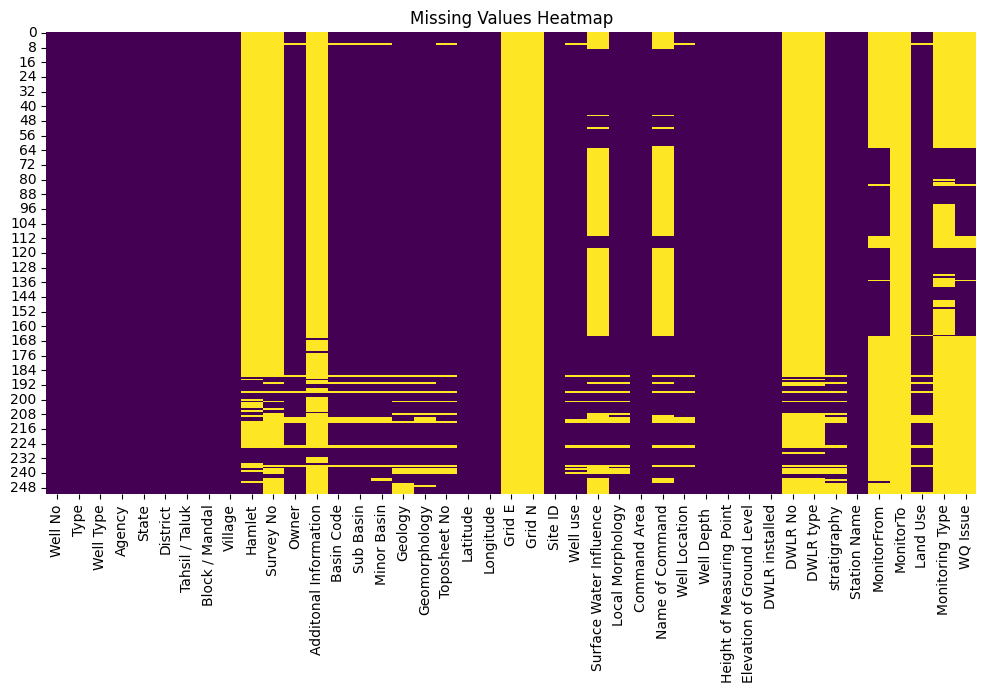

Columns with missing values:
Grid E                     100.000000
Grid N                     100.000000
MonitorTo                  100.000000
Additonal Information       94.444444
DWLR No                     89.682540
DWLR type                   89.682540
Survey No                   88.888889
Hamlet                      85.714286
Monitoring Type             79.365079
WQ Issue                    62.698413
MonitorFrom                 62.301587
Surface Water Influence     52.380952
Name of Command             48.015873
stratigraphy                 8.333333
Geology                      7.142857
Geomorphology                5.952381
Local Morphology             5.555556
Land Use                     5.158730
Toposheet No                 4.761905
Minor Basin                  4.761905
Well use                     4.365079
Basin Code                   3.968254
Sub Basin                    3.968254
Owner                        3.571429
Well Location                3.571429
dtype: float64

Numer

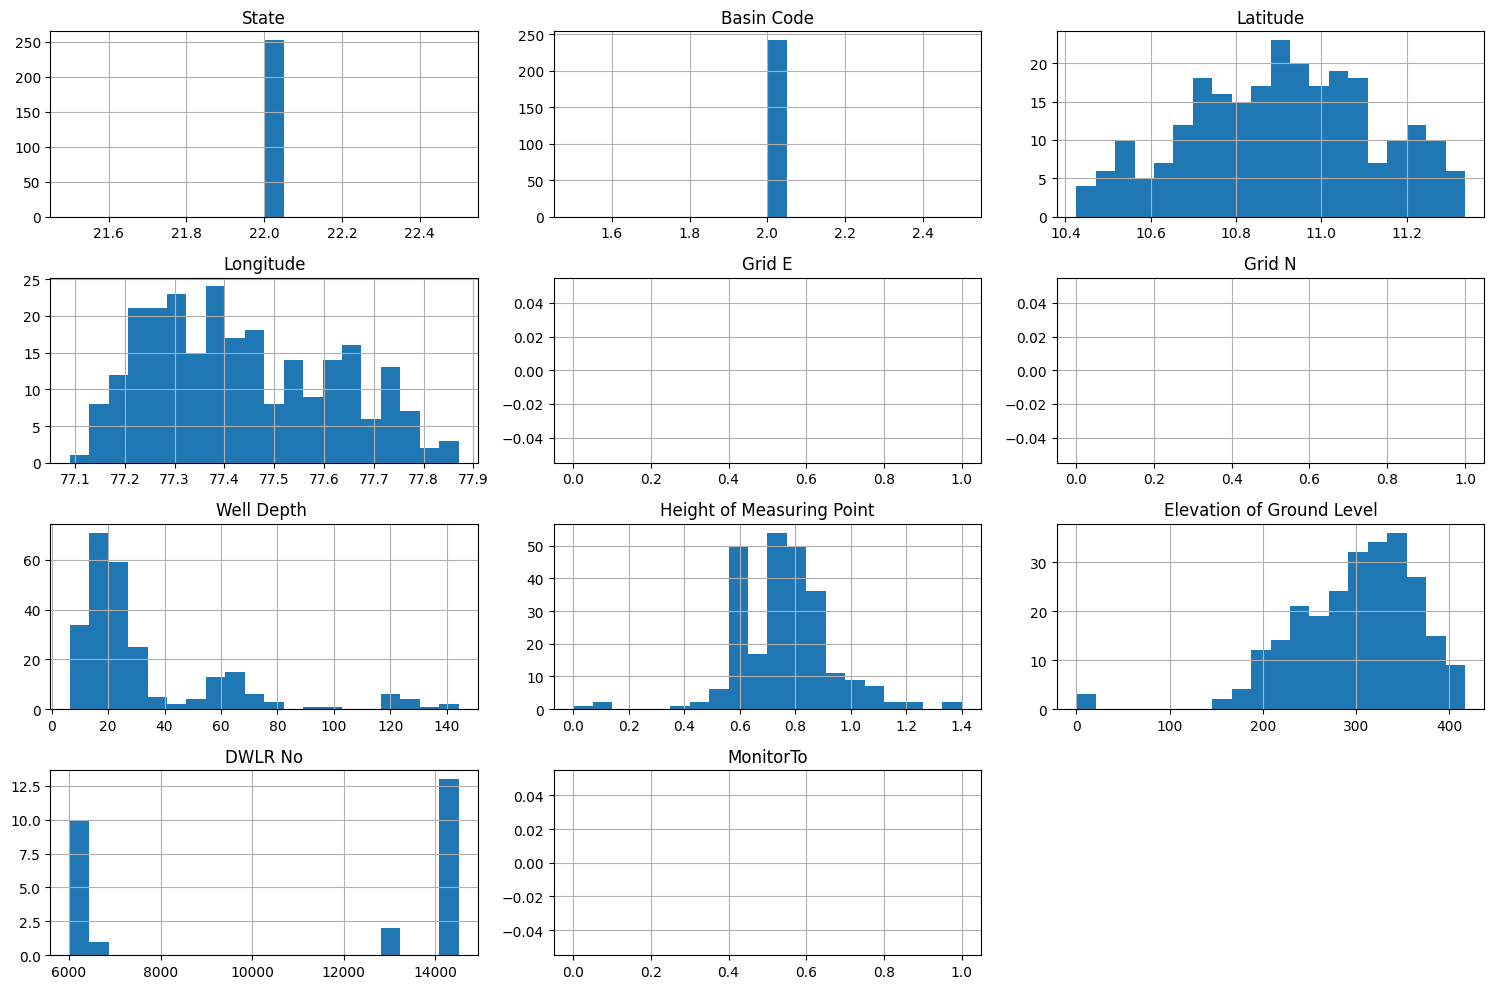

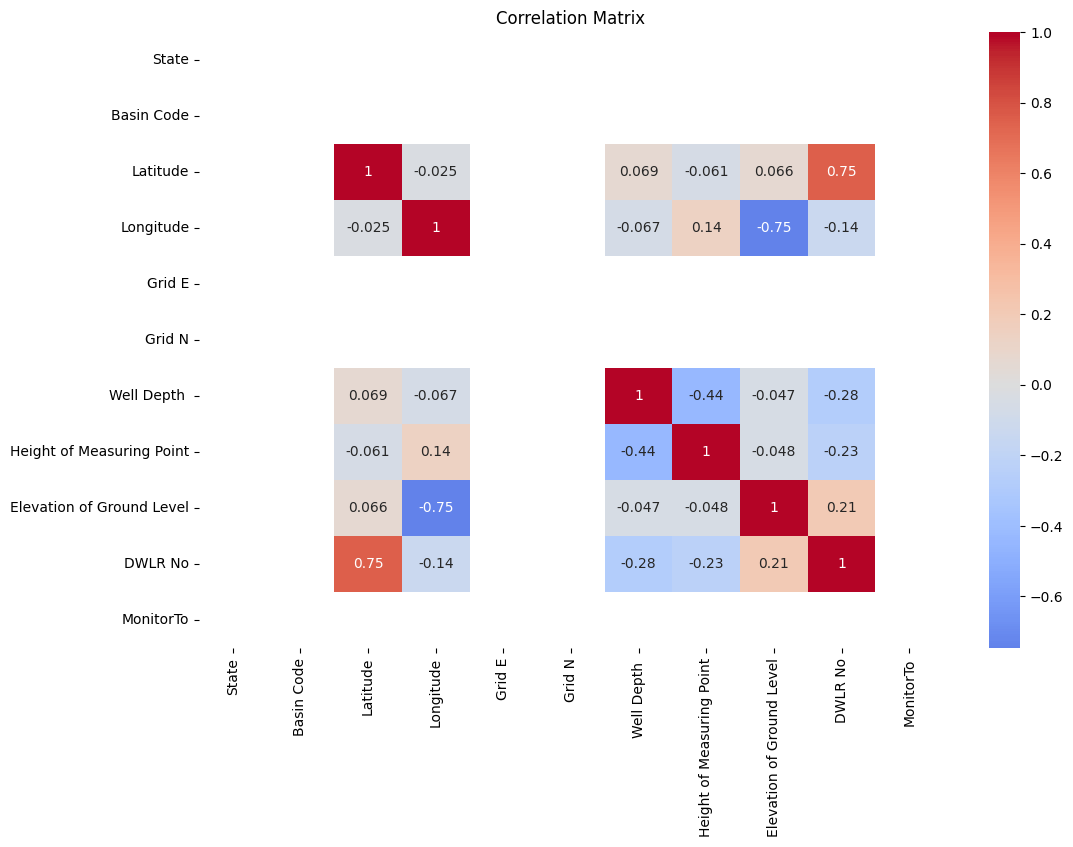

In [ ]:
# Check for missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Display missing values percentage
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing_percent)

# Numerical features analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNumerical columns: {list(numerical_cols)}")

# Categorical features analysis
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")

# Distribution of numerical features
df[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

**Preprocessing**

In [ ]:
# Define target variable - let's use 'Well Depth' as our target
# First, check if it has missing values and handle them
print(f"Missing values in 'Well Depth': {df['Well Depth '].isnull().sum()}")

# Drop rows with missing target values
df = df.dropna(subset=['Well Depth '])

# Select features for the model
# We'll use a subset of numerical features for this example
feature_cols = ['Latitude', 'Longitude', 'Elevation of Ground Level', 'Height of Measuring Point']
target_col = 'Well Depth '

# Handle missing values in features
for col in feature_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Create the feature matrix and target vector
X = df[feature_cols].values
y = df[target_col].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM (samples, time steps, features)
# Since we don't have time series data, we'll treat each sample as a sequence of 1 time step
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Missing values in 'Well Depth': 0
Training data shape: (201, 1, 4)
Testing data shape: (51, 1, 4)


**Model Building**

In [ ]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model architecture
model.summary()

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,301 (48.05 KB)

 Trainable params: 12,301 (48.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - loss: 2076.1160 - mae: 34.9413 - val_loss: 2385.3911 - val_mae: 36.4945
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1826.7738 - mae: 32.6262 - val_loss: 2381.8406 - val_mae: 36.4481
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2072.1758 - mae: 34.4097 - val_loss: 2378.3792 - val_mae: 36.4026
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2173.8325 - mae: 35.2748 - val_loss: 2374.9883 - val_mae: 36.3572
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1813.2506 - mae: 32.7034 - val_loss: 2371.5273 - val_mae: 36.3100
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2311.9207 - mae: 36.2918 - val_loss: 2367.8066 - val_mae: 36.2590
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1833.3942 - mae: 32.7367 - val_loss: 2363.7913 - val_mae: 36.2039
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1994.7091 - mae: 33.1357 - val_loss: 2359.2778 - val_mae: 36.1423
Epoch 9

**Plotting**

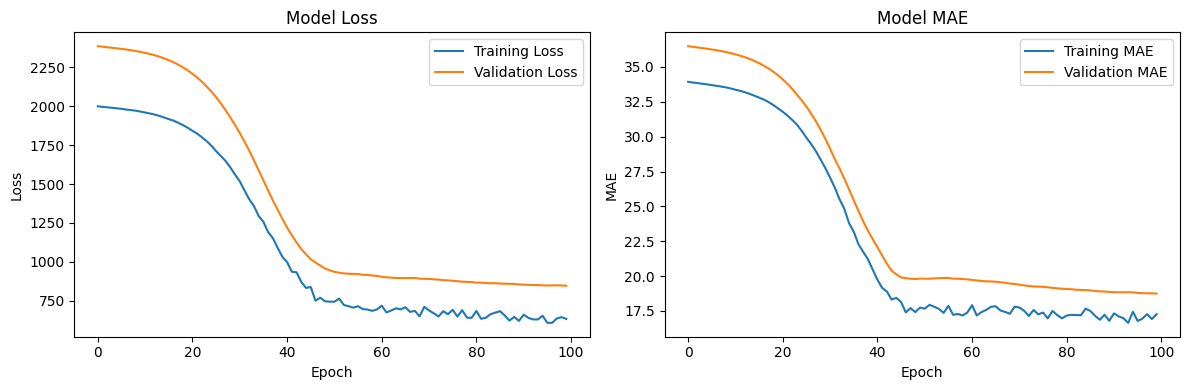

Training MAE: 17.35
Testing MAE: 18.05
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step


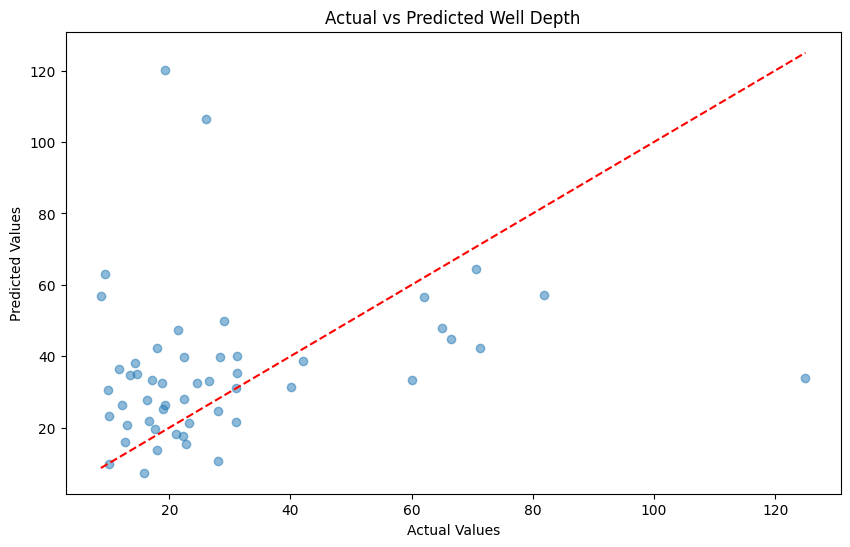

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model
train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Training MAE: {train_mae:.2f}")
print(f"Testing MAE: {test_mae:.2f}")

# Make predictions
y_pred = model.predict(X_test)

# Plot predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Well Depth')
plt.show()

**Saving the Model**

In [ ]:
# Save the model
model.save('/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/groundwater_general_lstm_model.h5')

# Save the scaler
import joblib
joblib.dump(scaler, '/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/scaler.pkl')

# Save the feature columns
import json
with open('/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!


**Prediction**

In [ ]:
# Load the model and preprocessing objects
loaded_model = tf.keras.models.load_model('/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/groundwater_general_lstm_model.h5', custom_objects={'mse': tf.keras.metrics.MeanSquaredError(), 'mae': tf.keras.metrics.MeanAbsoluteError()})
loaded_scaler = joblib.load('/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/scaler.pkl')

with open('/content/drive/My Drive/Tiruppur_Data/Models/Groundwater_General_Model/feature_columns.json', 'r') as f:
    loaded_feature_cols = json.load(f)

# Example of making a prediction with new data
new_data = np.array([[11.2, 77.4, 300, 0.8]])  # Example values
new_data_scaled = loaded_scaler.transform(new_data)
new_data_reshaped = new_data_scaled.reshape(1, 1, len(loaded_feature_cols))

prediction = loaded_model.predict(new_data_reshaped)
print(f"Predicted Well Depth: {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
Predicted Well Depth: 30.22


## **Groundwater Level Dataset**

**Setting Up**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/Tiruppur_Data/Ground_Water_Level.csv'  # Update this path
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (11644, 8)

First few rows:
  Well No Type        date  time  Ht of Ms Pt  Water Level (m) Remarks Flag
0   63324   OB  02-01-2017   NaN         0.81            37.89     NaN  NaN
1   63340   OB  02-01-2017   NaN         0.50            29.20     NaN  NaN
2   63335   OB  02-01-2017   NaN         0.82            28.08     NaN  NaN
3   63341   OB  02-01-2017   NaN         0.80            25.32     NaN  NaN
4   63338   OB  02-01-2017   NaN         0.70            21.70     NaN  NaN

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11644 entries, 0 to 11643
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Well No          11644 non-null  object 
 1   Type             11644 non-null  object 
 2   date             11644 non-null  object 
 3   time          

**EDA**

Date range: 2017-01-02 00:00:00 to 2023-12-07 00:00:00

Well Types:
Type
OB    9439
PZ    2205
Name: count, dtype: int64

Water Level unique values:
[37.89 29.2  28.08 25.32 21.7  18.57 17.2  15.05 12.86 11.64 10.03  6.8
   nan 53.75 26.92 25.3  24.05 20.75 20.1  19.7 ]

Missing values in Water Level: 1316


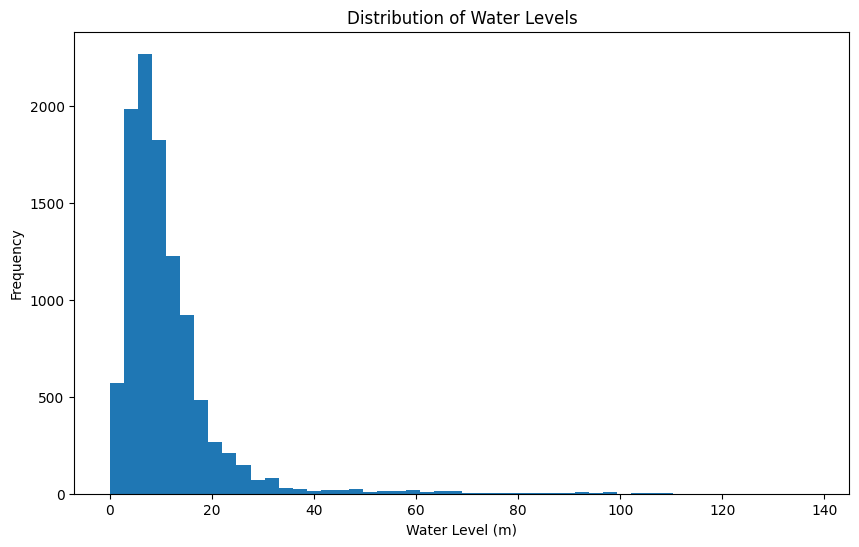

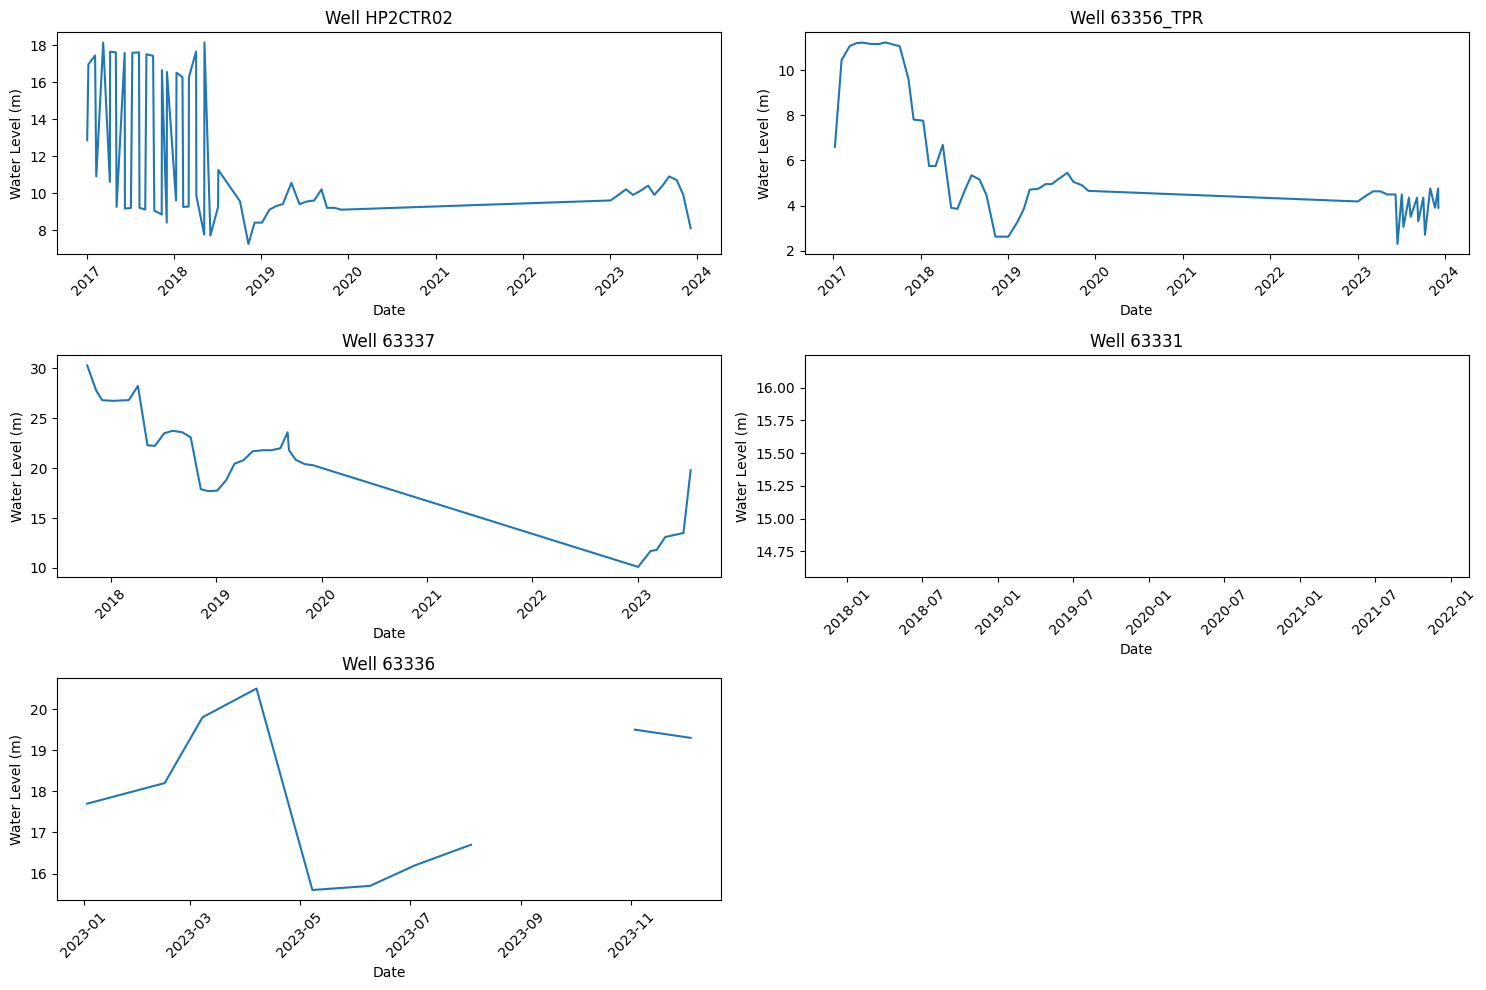

In [ ]:
# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Check the date range
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Check unique well types
print("\nWell Types:")
print(df['Type'].value_counts())

# Check for dry wells and other special values in Water Level
print("\nWater Level unique values:")
print(df['Water Level (m)'].unique()[:20])  # Show first 20 unique values

# Convert Water Level to numeric, handling special values
df['Water Level (m)'] = pd.to_numeric(df['Water Level (m)'], errors='coerce')

# Handle missing values in Water Level
print(f"\nMissing values in Water Level: {df['Water Level (m)'].isnull().sum()}")

# Plot distribution of water levels
plt.figure(figsize=(10, 6))
plt.hist(df['Water Level (m)'].dropna(), bins=50)
plt.title('Distribution of Water Levels')
plt.xlabel('Water Level (m)')
plt.ylabel('Frequency')
plt.show()

# Plot water levels over time for a few representative wells
wells_to_plot = df['Well No'].value_counts().index[:5]  # Top 5 wells by number of readings

plt.figure(figsize=(15, 10))
for i, well in enumerate(wells_to_plot):
    well_data = df[df['Well No'] == well].sort_values('date')
    plt.subplot(3, 2, i+1)
    plt.plot(well_data['date'], well_data['Water Level (m)'])
    plt.title(f'Well {well}')
    plt.xlabel('Date')
    plt.ylabel('Water Level (m)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Preprocessing**

In [ ]:
# For this example, let's focus on a single well with good data coverage
# Let's choose a well with many readings
well_counts = df['Well No'].value_counts()
selected_well = well_counts.index[0]  # Select the well with the most readings
print(f"Selected well: {selected_well} with {well_counts[0]} readings")

# Filter data for the selected well
well_data = df[df['Well No'] == selected_well].sort_values('date')

# Handle missing values in the time series
well_data = well_data.interpolate(method='linear')  # Time-based interpolation

# Prepare data for LSTM
data = well_data[['date', 'Water Level (m)']].set_index('date')

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:(i+seq_length), 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

# Set sequence length (number of time steps to look back)
seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Selected well: HP2CTR02 with 63 readings
Training data shape: (25, 30, 1)
Testing data shape: (7, 30, 1)


**Model Building**

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - loss: 0.0810 - val_loss: 0.0631
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0643 - val_loss: 0.0462
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0471 - val_loss: 0.0305
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0356 - val_loss: 0.0167
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0372 - val_loss: 0.0085
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0351 - val_loss: 0.0062
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0448 - val_loss: 0.0078
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0405 - val_loss: 0.0110
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0323 - val_loss: 0.0147
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0330 - val_loss: 0.0185
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0337 - val_loss: 0.0217
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0328 - v

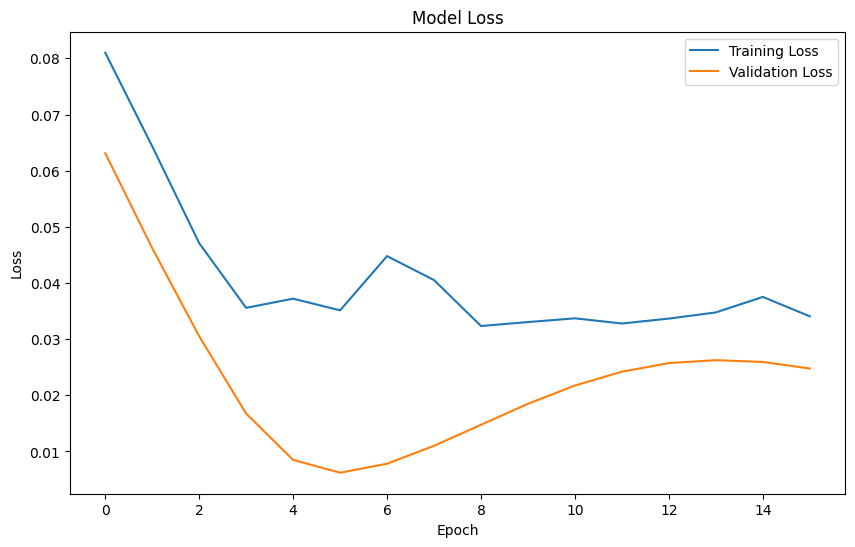

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

**Prdiction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
Train RMSE: 2.20
Test RMSE: 0.86
Train MAE: 1.56
Test MAE: 0.77


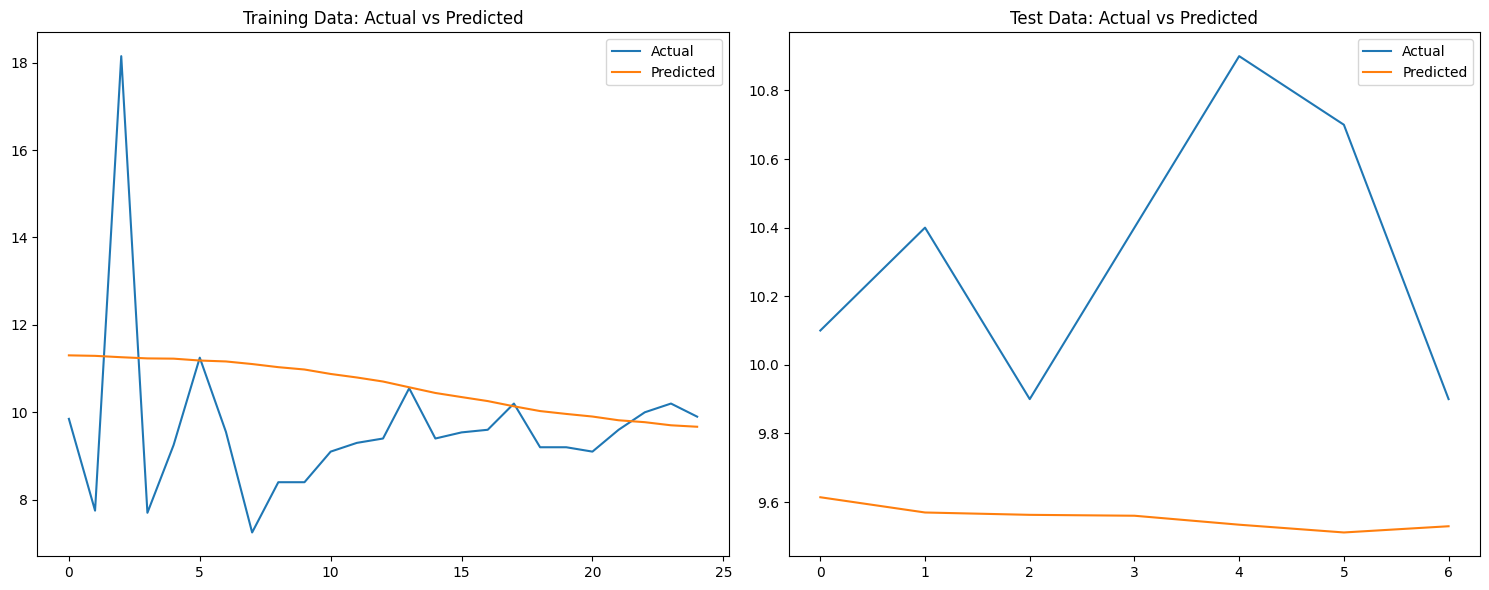

In [ ]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
train_mae = mean_absolute_error(y_train_actual, train_predict)
test_mae = mean_absolute_error(y_test_actual, test_predict)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")

# Plot predictions vs actual
plt.figure(figsize=(15, 6))

# Training data
plt.subplot(1, 2, 1)
plt.plot(y_train_actual, label='Actual')
plt.plot(train_predict, label='Predicted')
plt.title('Training Data: Actual vs Predicted')
plt.legend()

# Test data
plt.subplot(1, 2, 2)
plt.plot(y_test_actual, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.title('Test Data: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()

**Saving the Model**

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/Tiruppur_Data/Models/Groundwater_Level_Model/groundwater_level_lstm_model.h5')
print("Model saved successfully!")

# Also save the scaler for future use
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/Tiruppur_Data/Models/Groundwater_Level_Model/scaler.save')
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


## **Groundwater Quality Dataset**

**Setting Up**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset with specified encoding
file_path = '/content/drive/MyDrive/Tiruppur_Data/Ground_Water_Quality.csv'
data = pd.read_csv(file_path, encoding='latin-1')

# Display basic information about the dataset
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (340, 25)

First 5 rows:


,Well No,Well Type,District,Tahsil / Taluk,Village,Latitude,Longitude,Date of collection,TDS (mg/L),NO2+NO3 (mg/L),...,SO4 (mg/L),CO3 (mg/L),HCO3 (mg/L),F (mg/L),pH_GEN,EC_GEN (µS/cm),HAR_Total (mg/L),SAR,RSC (meq/L),Na%
0,HP2CTR02,Bore Well,Tiruppur,Avinashi,Sevur,"11°14'50""","77°14'30""",02-01-2017,300,12.0,...,37,2.483538,132.4167,0.36000,8.3,500,130,2.289645,0,48.90796
1,HP2CTR04,Bore Well,Tiruppur,Avinashi,Thathanur,"11°18'20""","77°16'40""",02-01-2017,180,1.0,...,13,2.483538,132.4167,0.26000,8.3,330,110,1.037130,0.05452959,32.09222
2,63542,Dug Well,Tiruppur,Kangeyam,Vellakoil,"10°56'40""","77°42'55""",04-01-2017,853,97.0,...,74,18.000000,305.0000,0.93138,8.8,1500,390,3.546679,0,46.27607
3,HP2ETR27,Bore Well,Tiruppur,Dharapuram,Thoorampadi,"10°51'05""","77°40'30""",04-01-2017,1280,116.0,...,134,18.000000,658.8000,1.47000,8.8,2240,350,8.022918,4.401241,67.88406
4,HP2ETR29,Bore Well,Tiruppur,Dharapuram,Velampoondi,"10°48'40""","77°53'00""",04-01-2017,1280,113.0,...,172,0.000000,549.0000,0.74000,8.0,2280,490,5.699535,0,55.58850


**EDA**

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Well No             340 non-null    object 
 1   Well Type           340 non-null    object 
 2   District            340 non-null    object 
 3   Tahsil / Taluk      340 non-null    object 
 4   Village             340 non-null    object 
 5   Latitude            340 non-null    object 
 6   Longitude           340 non-null    object 
 7   Date of collection  340 non-null    object 
 8   TDS (mg/L)          340 non-null    int64  
 9   NO2+NO3 (mg/L)      340 non-null    float64
 10  Ca (mg/L)           340 non-null    float64
 11  Mg (mg/L)           340 non-null    float64
 12  Na (mg/L)           340 non-null    int64  
 13  K (mg/L)            340 non-null    int64  
 14  Cl (mg/L)           340 non-null    int64  
 15  SO4 (mg/L)          340 non-null    int64  

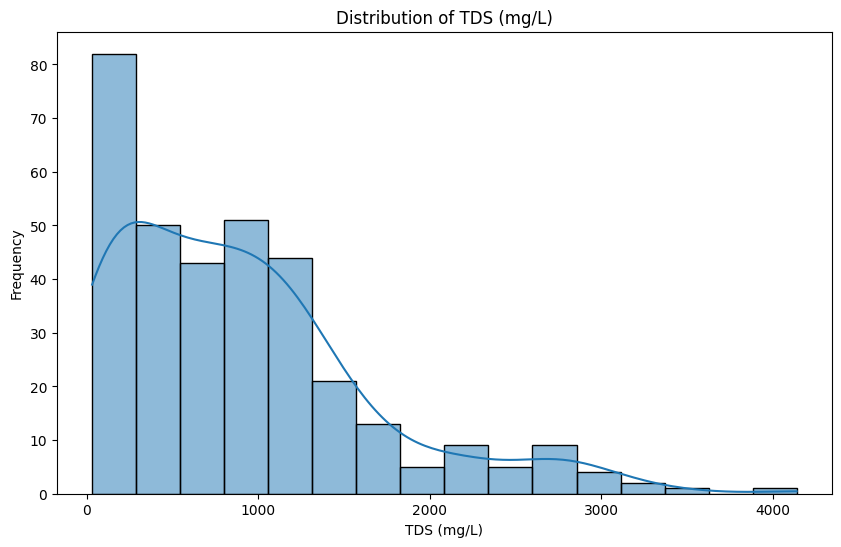

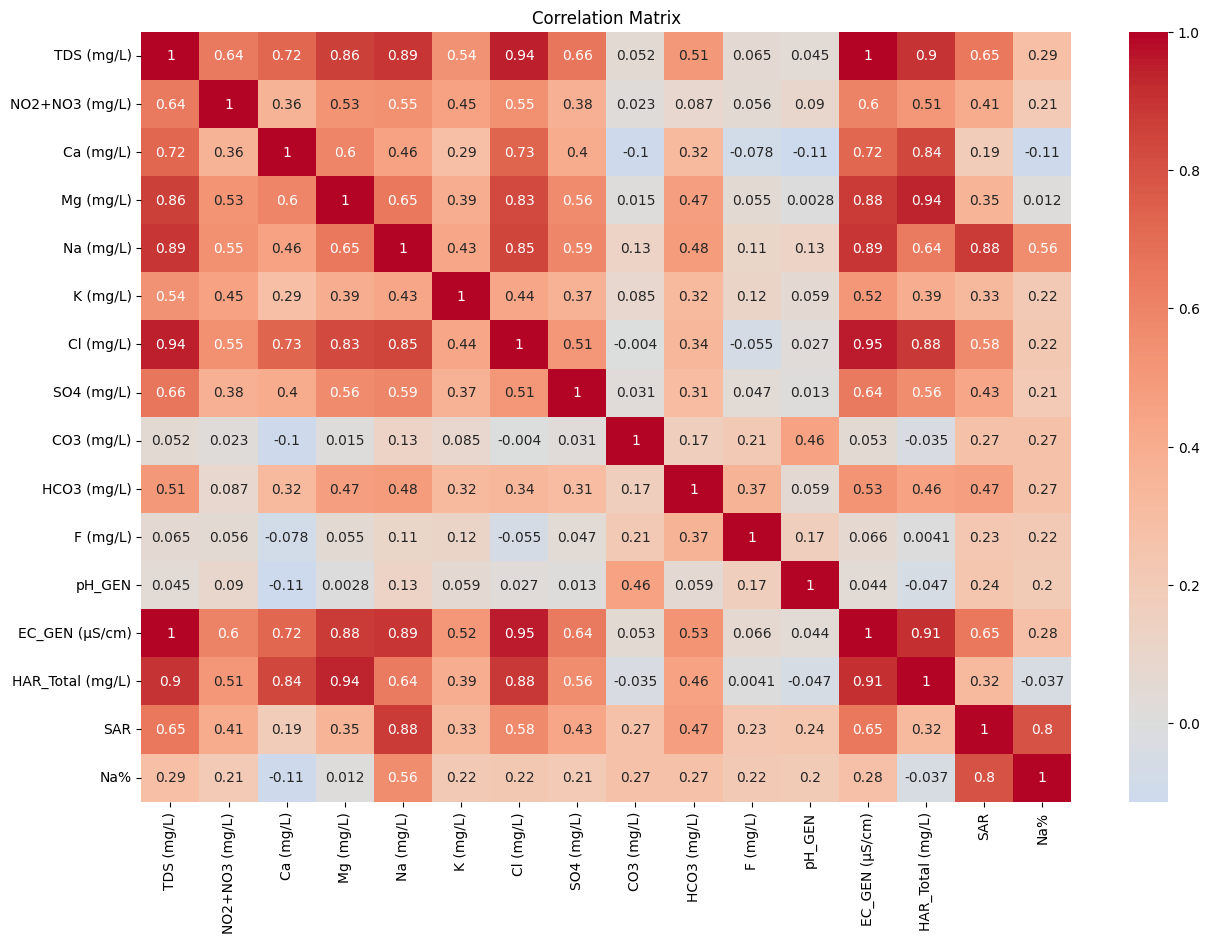

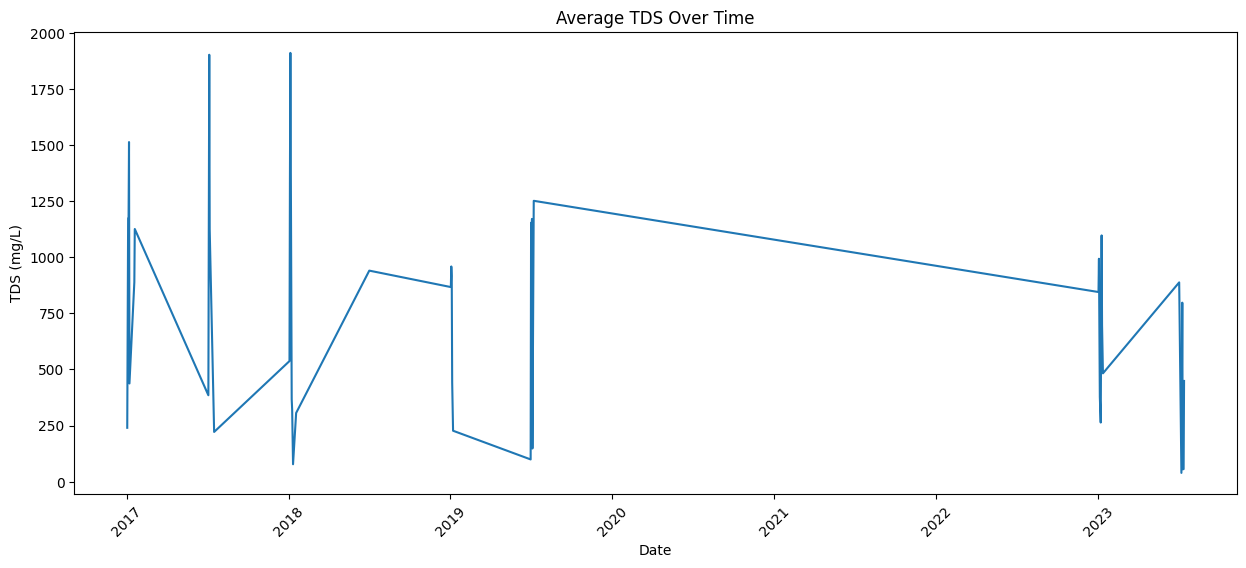

In [ ]:
# Data information
print("Dataset Info:")
data.info()

# Check for missing values
print("Missing Values:")
print(data.isnull().sum())

# Statistical summary
data.describe()

# Check unique values in categorical columns
categorical_cols = ['Well No', 'Well Type', 'District', 'Tahsil / Taluk', 'Village']
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")

# Convert date column to datetime
data['Date of collection'] = pd.to_datetime(data['Date of collection'], dayfirst=True)
print(f"Date range: {data['Date of collection'].min()} to {data['Date of collection'].max()}")

# Visualize the distribution of the target variable (TDS)
plt.figure(figsize=(10, 6))
sns.histplot(data['TDS (mg/L)'], kde=True)
plt.title('Distribution of TDS (mg/L)')
plt.xlabel('TDS (mg/L)')
plt.ylabel('Frequency')
plt.show()

# Correlation matrix
plt.figure(figsize=(15, 10))
numeric_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Time series of TDS
plt.figure(figsize=(15, 6))
time_series_data = data.groupby('Date of collection')['TDS (mg/L)'].mean()
plt.plot(time_series_data.index, time_series_data.values)
plt.title('Average TDS Over Time')
plt.xlabel('Date')
plt.ylabel('TDS (mg/L)')
plt.xticks(rotation=45)
plt.show()

**Preprocessing**

In [ ]:
# Preprocessing function
def preprocess_data(df, target_column='TDS (mg/L)', sequence_length=10):
    # Create a copy of the dataframe
    df_processed = df.copy()

    # Convert date to ordinal for modeling
    df_processed['Date_ordinal'] = df_processed['Date of collection'].apply(lambda x: x.toordinal())

    # Encode categorical variables
    categorical_cols = ['Well Type', 'District', 'Tahsil / Taluk']
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))

    # Convert 'RSC (meq/L)' to numeric, coercing errors
    df_processed['RSC (meq/L)'] = pd.to_numeric(df_processed['RSC (meq/L)'], errors='coerce')

    # Select features - excluding identifiers and high cardinality columns, and now Latitude/Longitude
    feature_cols = ['Well Type', 'District', 'Tahsil / Taluk', # 'Latitude', 'Longitude', # Dropping these due to format
                   'Date_ordinal', 'NO2+NO3 (mg/L)', 'Ca (mg/L)', 'Mg (mg/L)',
                   'Na (mg/L)', 'K (mg/L)', 'Cl (mg/L)', 'SO4 (mg/L)', 'CO3 (mg/L)',
                   'HCO3 (mg/L)', 'F (mg/L)', 'pH_GEN', 'EC_GEN (µS/cm)',
                   'HAR_Total (mg/L)', 'SAR', 'RSC (meq/L)', 'Na%'] # Keep RSC after conversion

    # Check if all columns exist
    feature_cols = [col for col in feature_cols if col in df_processed.columns]

    # Extract features and target
    X = df_processed[feature_cols]
    y = df_processed[target_column]

    # Handle missing values in features and target AFTER converting RSC
    X = X.fillna(X.mean())
    y = y.fillna(y.mean())

    # Standardize features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Create sequences for LSTM
    X_sequences = []
    y_sequences = []

    for i in range(len(X_scaled) - sequence_length):
        X_sequences.append(X_scaled[i:i+sequence_length])
        y_sequences.append(y_scaled[i+sequence_length])

    return np.array(X_sequences), np.array(y_sequences), scaler_X, scaler_y, feature_cols

# Preprocess the data
sequence_length = 10
X, y, scaler_X, scaler_y, feature_cols = preprocess_data(data, sequence_length=sequence_length)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

X shape: (330, 10, 20)
y shape: (330,)
Training data shape: (264, 10, 20), (264,)
Testing data shape: (66, 10, 20), (66,)


**Model Building**

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 1.2310 - mae: 0.8382 - val_loss: 0.7189 - val_mae: 0.6761
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1719 - mae: 0.8251 - val_loss: 0.7107 - val_mae: 0.6769
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1166 - mae: 0.8125 - val_loss: 0.7092 - val_mae: 0.6747
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0701 - mae: 0.8028 - val_loss: 0.7125 - val_mae: 0.6740
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0349 - mae: 0.7953 - val_loss: 0.7182 - val_mae: 0.6738
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9721 - mae: 0.7621 - val_loss: 0.7174 - val_mae: 0.6739
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0018 - mae: 0.7890 - val_loss: 0.7186 - val_mae: 0.6762
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9304 - mae: 0.7622 - val_loss: 0.7213 - val_mae: 0.6770
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8982 - mae: 

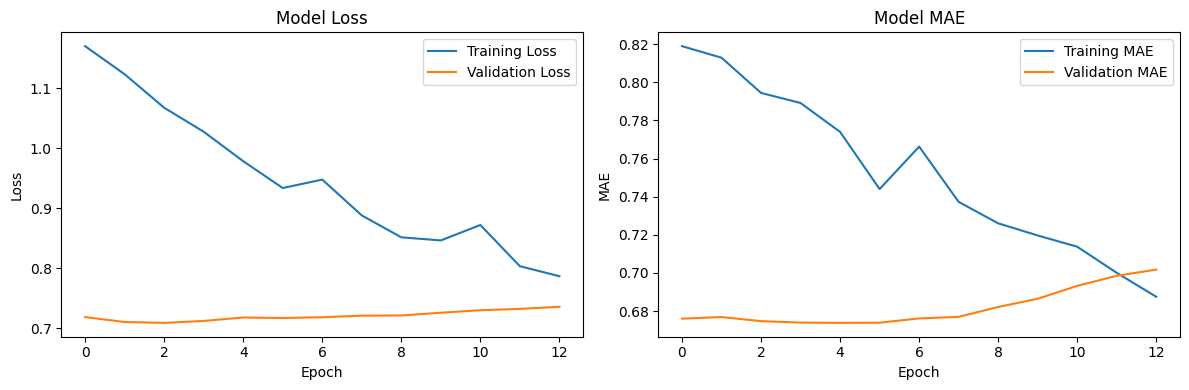

In [ ]:
# Build LSTM model
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])

    return model

# Create model
input_shape = (X_train.shape[1], X_train.shape[2])
model = create_lstm_model(input_shape)

# Display model summary
model.summary()

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

**Prediction**

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Mean Squared Error: 399903.71
Mean Absolute Error: 519.23
R² Score: -0.05


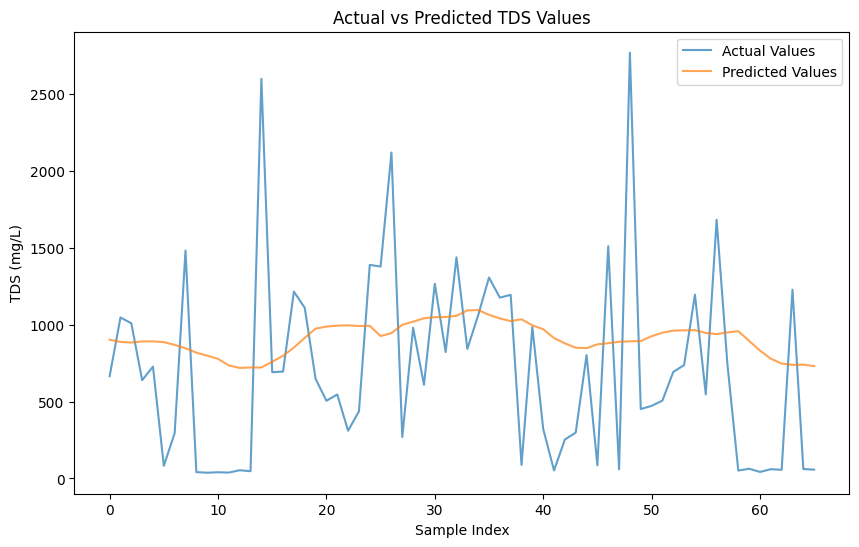

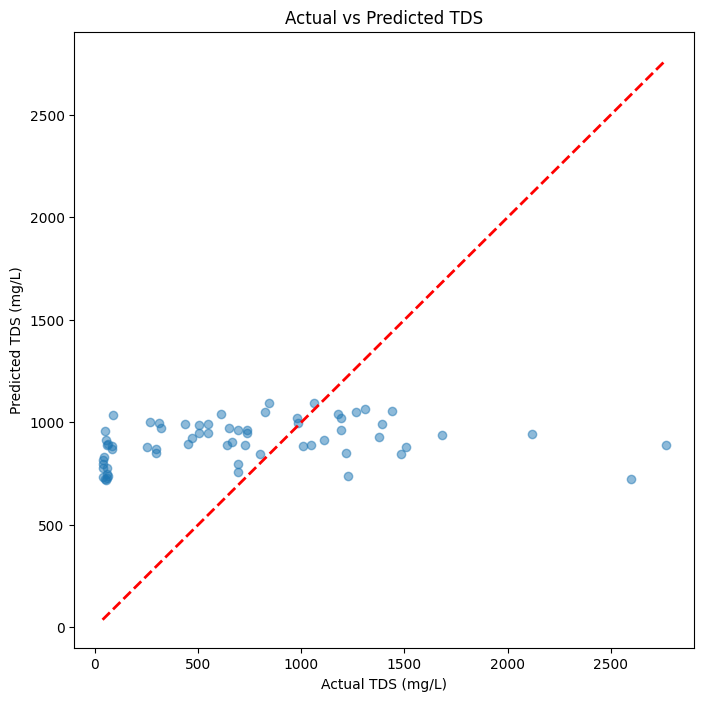

In [ ]:
# Make predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual Values', alpha=0.7)
plt.plot(y_pred, label='Predicted Values', alpha=0.7)
plt.title('Actual vs Predicted TDS Values')
plt.xlabel('Sample Index')
plt.ylabel('TDS (mg/L)')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual TDS (mg/L)')
plt.ylabel('Predicted TDS (mg/L)')
plt.title('Actual vs Predicted TDS')
plt.show()

**Saving the Model**

In [ ]:
# Save the model
model.save('/content/drive/MyDrive/Tiruppur_Data/Models/Groundwater_Quality_Model/groundwater_lstm_model.h5')

# Save the scalers
import joblib
joblib.dump(scaler_X, '/content/drive/MyDrive/Tiruppur_Data/Models/Groundwater_Quality_Model/scaler_X.pkl')
joblib.dump(scaler_y, '/content/drive/MyDrive/Tiruppur_Data/Models/Groundwater_Quality_Model/scaler_y.pkl')

print("Model and scalers saved successfully!")

Model and scalers saved successfully!


## **Rainfall Data**

**Setting Up**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set style for plots
plt.style.use('fivethirtyeight')

# Load the dataset
file_path = '/content/drive/MyDrive/Tiruppur_Data/Tiruppur_RFD.csv'  # Update with your actual path
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (7792, 4)

First few rows:
       dist    station  value        date
0  Tiruppur  Udumalpet    7.6  28-01-2007
1  Tiruppur   Palladam    4.2  28-01-2007
2  Tiruppur   Avinashi    1.0  28-01-2007
3  Tiruppur   Avinashi    2.0  18-02-2007
4  Tiruppur  Udumalpet   49.0  15-04-2007

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7792 entries, 0 to 7791
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dist     7792 non-null   object 
 1   station  7792 non-null   object 
 2   value    7792 non-null   float64
 3   date     7792 non-null   object 
dtypes: float64(1), object(3)
memory usage: 243.6+ KB
None

Basic Statistics:
             value
count  7792.000000
mean     14.248985
std      18.908733
min       0.020000
25%       3.000000
50%       7.000000
75%      18.00000

**Preprocessing**

In [ ]:
# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

# Check station names and clean if needed
print("Unique Stations:", df['station'].unique())

# Standardize station names (correct any inconsistencies)
df['station'] = df['station'].str.strip().str.lower()
df['station'] = df['station'].replace({'district collector office': 'collector office',
                                      'moolanur': 'mulanur'})

print("Cleaned Station Names:", df['station'].unique())

# Create a pivot table with dates as index and stations as columns
pivot_df = df.pivot_table(index='date', columns='station', values='value', aggfunc='mean')

# Fill missing values with 0 (assuming no rainfall)
pivot_df = pivot_df.fillna(0)

# Display the pivoted data
print("Pivoted Data Shape:", pivot_df.shape)
print("\nPivoted Data Head:")
print(pivot_df.head())

Unique Stations: ['Udumalpet' 'Palladam' 'Avinashi' 'District Collector Office' 'Kangeyam'
 'moolanur' 'Dharapuram' 'Amaravathy Dam' 'Thirumoorthi Dam'
 'Madathukulam' 'Thirumoorthy IB' 'Tiruppur North Taluk Office'
 'Tiruppur South Taluk Office' 'Vellakoil' 'Kundadam' 'Uthukuli'
 'PWD IB,(Collector Camp Office)' 'Nallathangal Odai Reservoir'
 'Vattamalai Karai Odai Reservoir' 'Uppar dam']
Cleaned Station Names: ['udumalpet' 'palladam' 'avinashi' 'collector office' 'kangeyam' 'mulanur'
 'dharapuram' 'amaravathy dam' 'thirumoorthi dam' 'madathukulam'
 'thirumoorthy ib' 'tiruppur north taluk office'
 'tiruppur south taluk office' 'vellakoil' 'kundadam' 'uthukuli'
 'pwd ib,(collector camp office)' 'nallathangal odai reservoir'
 'vattamalai karai odai reservoir' 'uppar dam']
Pivoted Data Shape: (1785, 20)

Pivoted Data Head:
station     amaravathy dam  avinashi  collector office  dharapuram  kangeyam  \
date                                                                           
2007-01

**EDA**

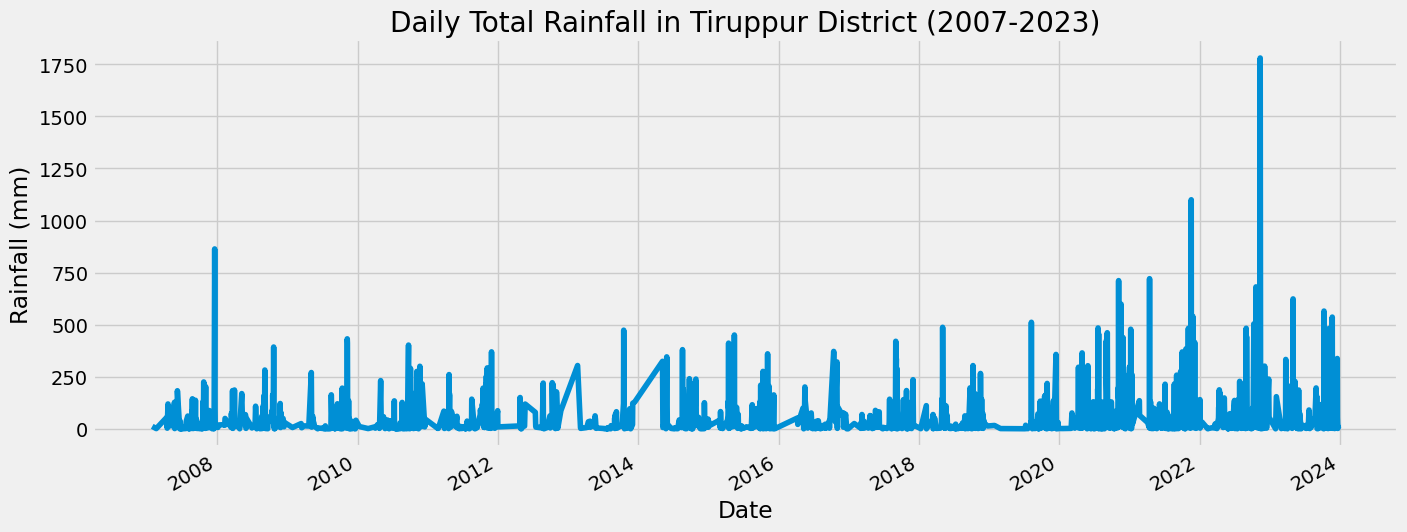

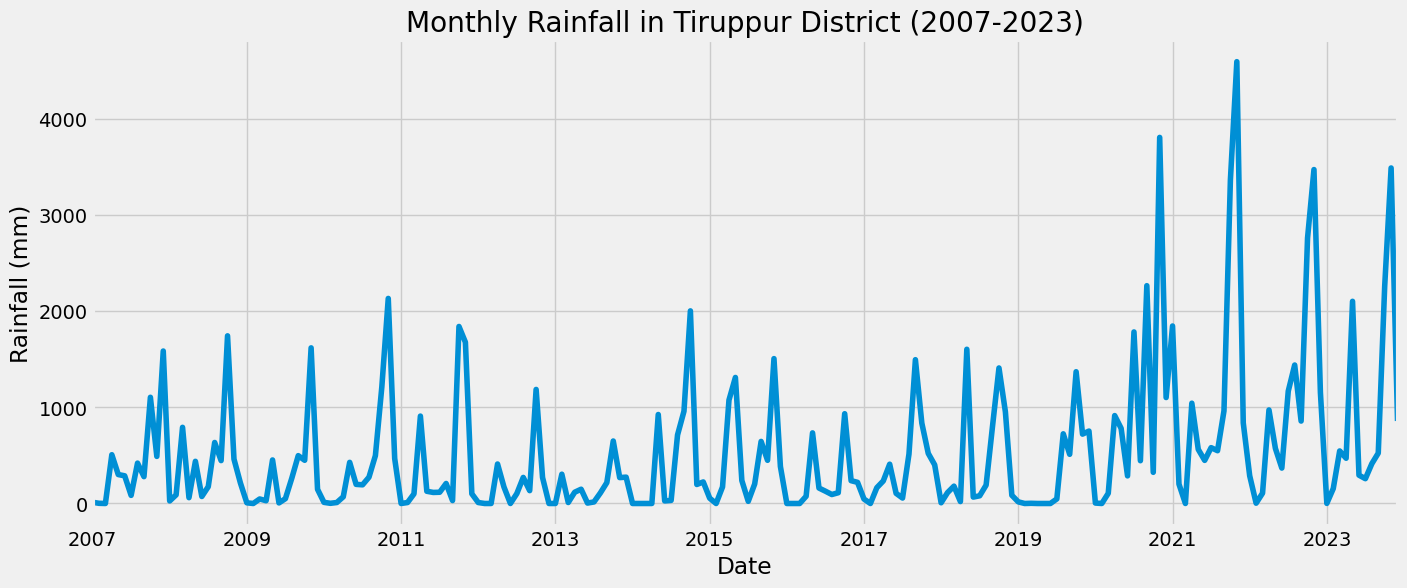

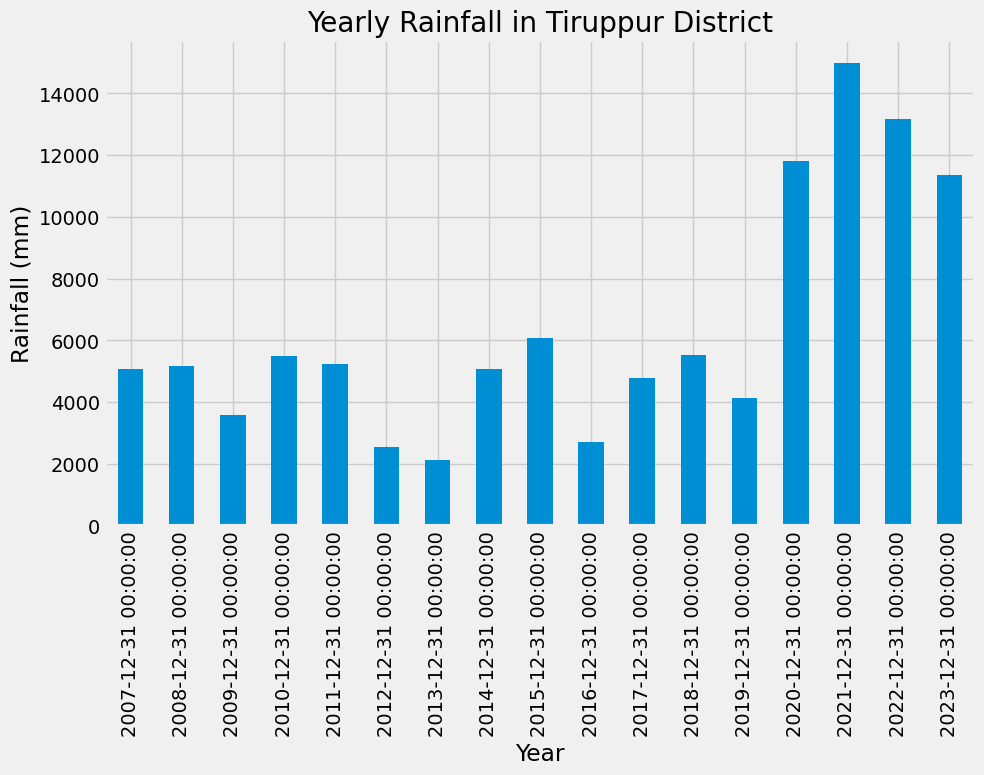

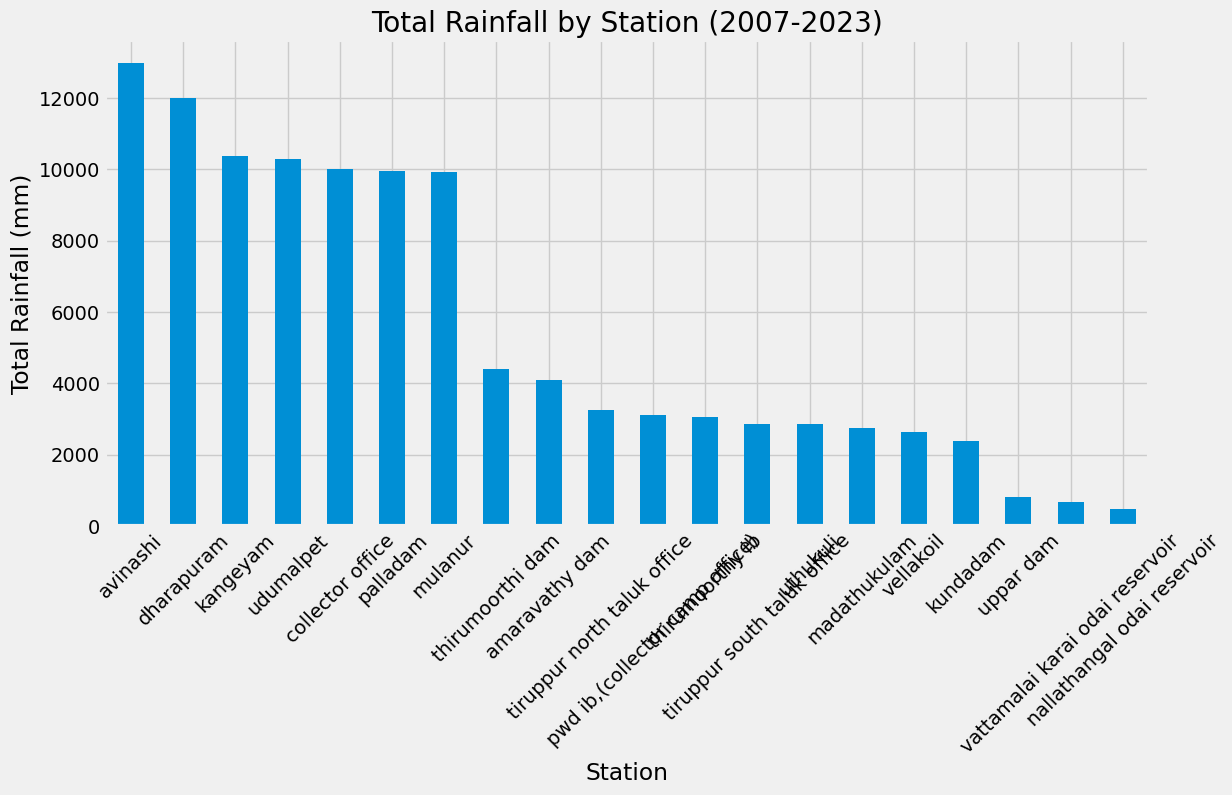

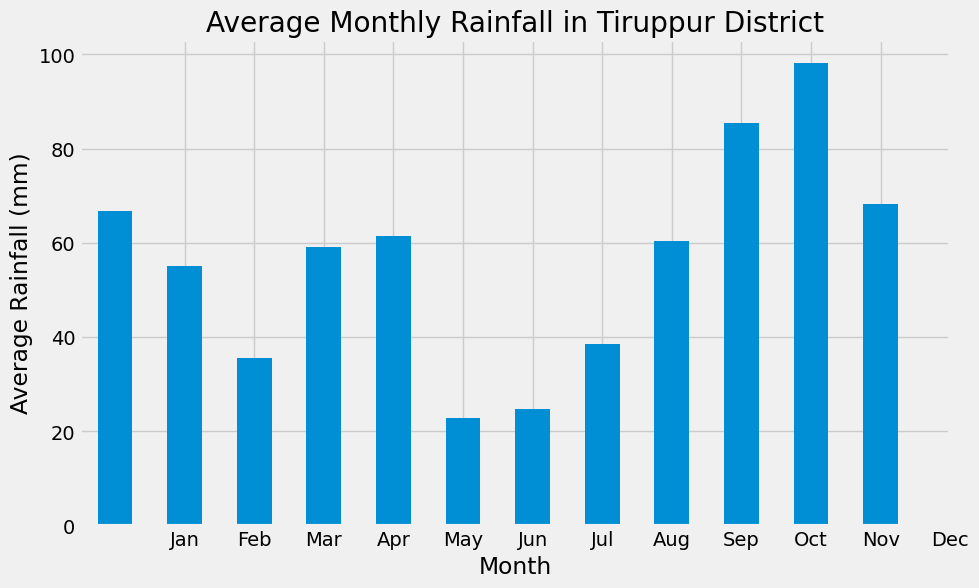

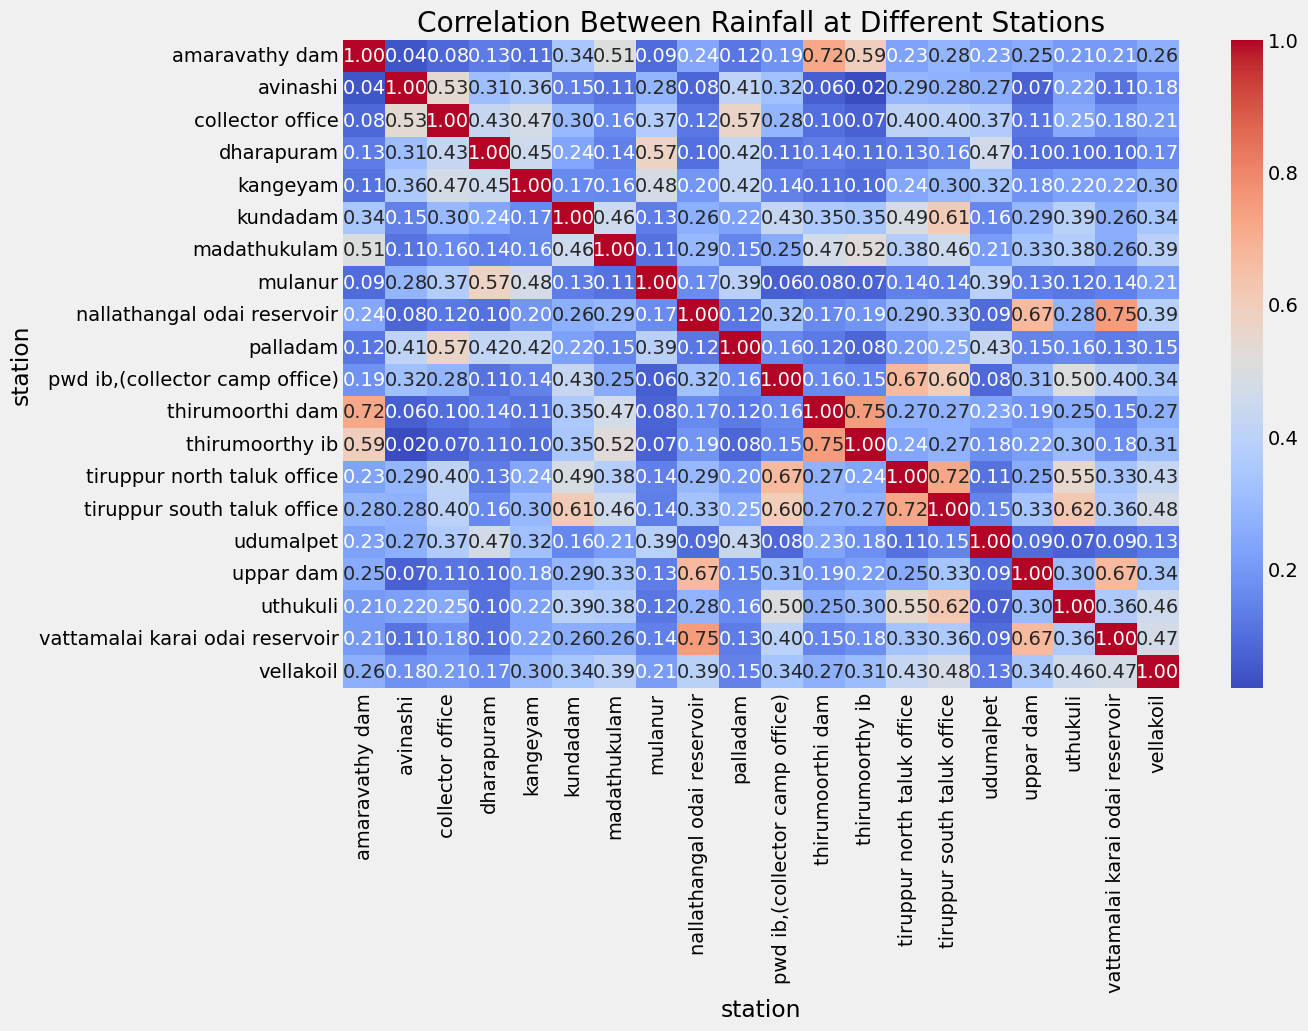

In [ ]:
# 1. Time series of total rainfall
daily_total = pivot_df.sum(axis=1)
plt.figure(figsize=(15, 6))
daily_total.plot(title='Daily Total Rainfall in Tiruppur District (2007-2023)')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Date')
plt.show()

# 2. Monthly rainfall patterns
monthly_rainfall = daily_total.resample('M').sum()
plt.figure(figsize=(15, 6))
monthly_rainfall.plot(title='Monthly Rainfall in Tiruppur District (2007-2023)')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Date')
plt.show()

# 3. Yearly rainfall trends
yearly_rainfall = daily_total.resample('Y').sum()
plt.figure(figsize=(10, 6))
yearly_rainfall.plot(kind='bar', title='Yearly Rainfall in Tiruppur District')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Year')
plt.show()

# 4. Station-wise analysis
station_totals = pivot_df.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
station_totals.plot(kind='bar', title='Total Rainfall by Station (2007-2023)')
plt.ylabel('Total Rainfall (mm)')
plt.xlabel('Station')
plt.xticks(rotation=45)
plt.show()

# 5. Seasonal analysis
# Extract month from the index and create a new Series for grouping
daily_total_with_month = pd.Series(daily_total.values, index=daily_total.index.month)
monthly_avg = daily_total_with_month.groupby(daily_total_with_month.index).mean()

plt.figure(figsize=(10, 6))
monthly_avg.plot(kind='bar', title='Average Monthly Rainfall in Tiruppur District')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Month')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.show()

# 6. Correlation between stations
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Rainfall at Different Stations')
plt.show()

**Model Building**

Training data shape: (1397, 30, 1)
Testing data shape: (326, 30, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0031 - val_loss: 0.0084
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - val_loss: 0.0083
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029 - val_loss: 0.0084
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0028 - val_loss: 0.0083
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

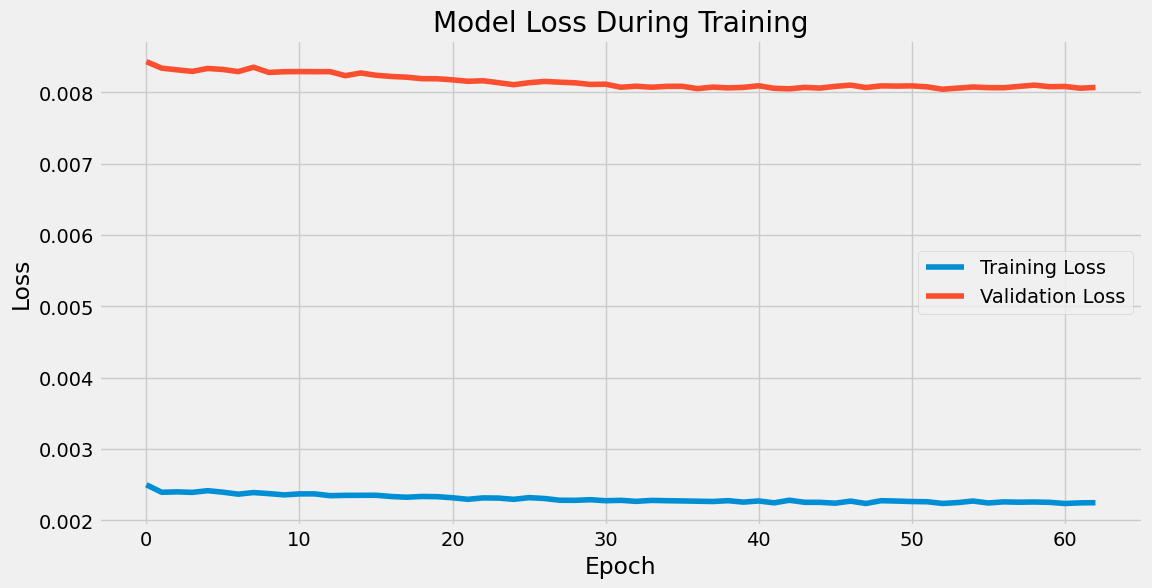

In [ ]:
# Use total daily rainfall as our target variable
series = daily_total.values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series)

# Split into train and test sets (use 80% for training)
train_size = int(len(series_scaled) * 0.8)
test_size = len(series_scaled) - train_size
train_data, test_data = series_scaled[0:train_size,:], series_scaled[train_size:len(series_scaled),:]

# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Create datasets for training and testing
look_back = 30  # Use 30 days to predict the next day
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

# Define early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

**Prediction**

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train RMSE: 84.01
Test RMSE: 159.61
Train MAE: 54.01
Test MAE: 81.47


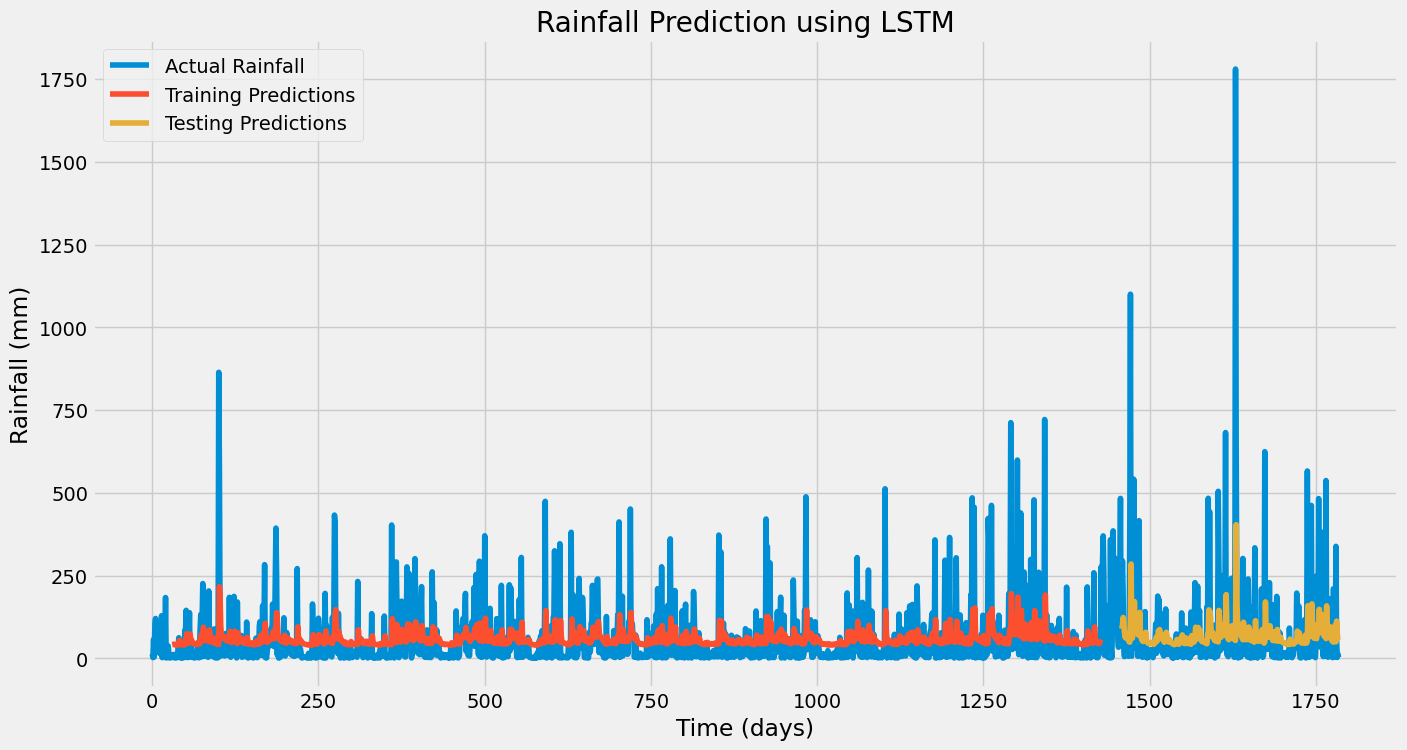

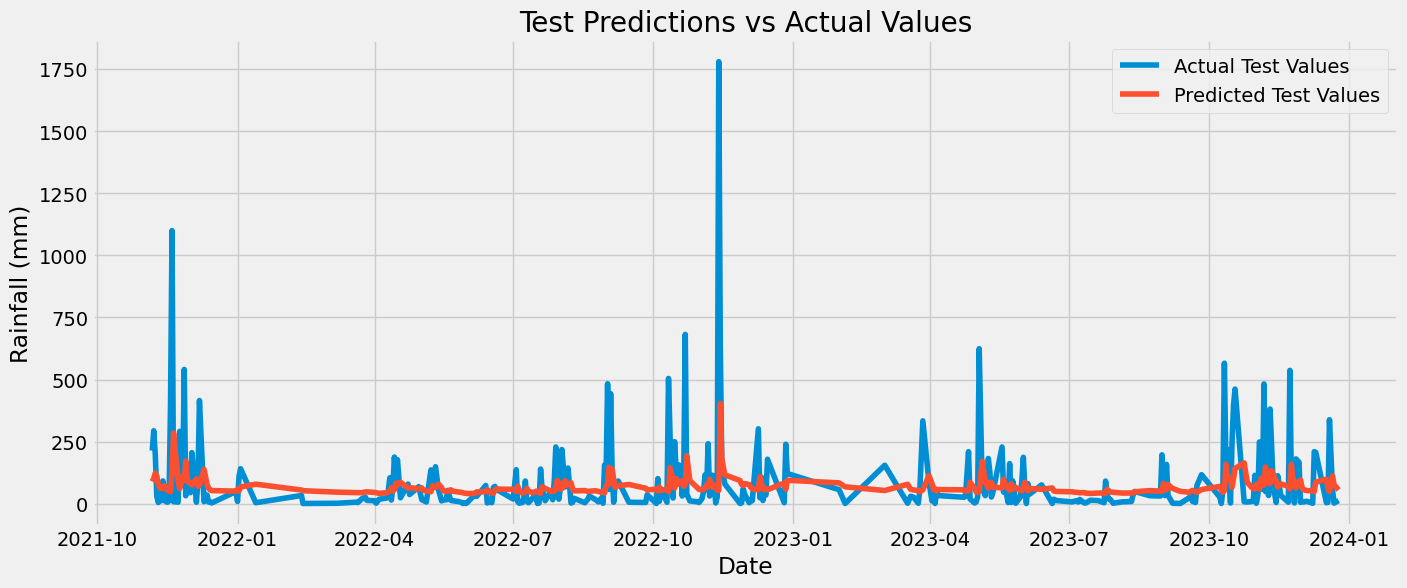

In [ ]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform([y_test])

# Calculate RMSE and MAE
train_rmse = np.sqrt(mean_squared_error(y_train_actual[0], train_predict[:,0]))
test_rmse = np.sqrt(mean_squared_error(y_test_actual[0], test_predict[:,0]))
train_mae = mean_absolute_error(y_train_actual[0], train_predict[:,0])
test_mae = mean_absolute_error(y_test_actual[0], test_predict[:,0])

print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Train MAE: {train_mae:.2f}')
print(f'Test MAE: {test_mae:.2f}')

# Shift train predictions for plotting
train_predict_plot = np.empty_like(series_scaled)
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:len(train_predict)+look_back, :] = train_predict

# Shift test predictions for plotting
test_predict_plot = np.empty_like(series_scaled)
test_predict_plot[:, :] = np.nan
test_predict_plot[len(train_predict)+(look_back*2)+1:len(series_scaled)-1, :] = test_predict

# Plot baseline and predictions
plt.figure(figsize=(15, 8))
plt.plot(scaler.inverse_transform(series_scaled), label='Actual Rainfall')
plt.plot(train_predict_plot, label='Training Predictions')
plt.plot(test_predict_plot, label='Testing Predictions')
plt.title('Rainfall Prediction using LSTM')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Time (days)')
plt.legend()
plt.show()

# Zoom in on test predictions
test_dates = daily_total.index[train_size+look_back+1:train_size+look_back+1+len(test_predict)]
plt.figure(figsize=(15, 6))
plt.plot(test_dates, y_test_actual[0], label='Actual Test Values')
plt.plot(test_dates, test_predict[:,0], label='Predicted Test Values')
plt.title('Test Predictions vs Actual Values')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Date')
plt.legend()
plt.show()

**Saving the Model**

In [ ]:
# Save the trained model
model.save('/content/drive/MyDrive/Tiruppur_Data/Models/Rainfall_Model/rainfall_lstm_model.h5')
print("Model saved successfully!")

# Save the scaler for future use
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/Tiruppur_Data/Models/Rainfall_Model/rainfall_scaler.pkl')
print("Scaler saved successfully!")

# Also save the look_back value for future reference
with open('/content/drive/MyDrive/Tiruppur_Data/Models/Rainfall_Model/model_config.txt', 'w') as f:
    f.write(f"look_back: {look_back}")
print("Model configuration saved!")

Model saved successfully!
Scaler saved successfully!
Model configuration saved!
